In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    answer: str
    tax_base_equation: str # 과세표준 계산 수식
    tax_deduction: str # 공제액
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산
    # 세율 계산 = answer

graph_builder = StateGraph(AgentState)

/Users/leehk/.pyenv/versions/tutorial-langchain/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


## PDF Embedding

- pdf -> md -> text -> split -> vector store

In [2]:
import nest_asyncio
nest_asyncio.apply()

### PDF to MD

In [3]:
from pyzerox import zerox
import os
import json
import asyncio

### Model Setup (Use only Vision Models) Refer: https://docs.litellm.ai/docs/providers ###

## placeholder for additional model kwargs which might be required for some models
kwargs = {}

## system prompt to use for the vision model
custom_system_prompt = None

###################### Example for OpenAI ######################
model = "gpt-4o-mini" ## openai model
#os.environ["OPENAI_API_KEY"] = "" ## your-api-key

###################### For other providers refer: https://docs.litellm.ai/docs/providers ######################

# Define main async entrypoint
async def main():
    file_path = './estate-tax.pdf'

    ## process only some pages or all
    select_pages = None ## None for all, but could be int or list(int) page numbers (1 indexed)

    output_dir = "./documents" ## directory to save the consolidated markdown file
    result = await zerox(file_path=file_path, model=model, output_dir=output_dir,
                        custom_system_prompt=custom_system_prompt,select_pages=select_pages, **kwargs)
    return result


# run the main function:
result = asyncio.run(main())

# print markdown result
print(result)

ZeroxOutput(completion_time=46090.116, file_name='estate_tax', input_tokens=368770, output_tokens=11444, pages=[Page(content='# 종합부동산세법\n[시행 2026. 1. 1.] [법률 제2112242호, 2025. 12. 23., 일부개정]  \n재정경제부 (재산세제과) 044-215-4313\n\n## 제1장 총칙\n\n### 제1조(목적) \n이 법은 고액의 부동산 보유자에 대하여 종합부동산세를 부과하여 부동산 보유에 대한 조세부담의 형평성을 제고하고, 부동산 가격상승을 도모함으로써 지방재정의 균형발전과 국민경제의 건전한 발전에 이바지함을 목적으로 한다.\n\n### 제2조(정의) \n이 법에서 사용하는 용어의 정의는 다음과 같다. <개정 2005. 12. 31., 2010. 3. 31., 2016. 1. 19., 2018. 12. 31., 2020. 6. 9., 2023. 3. 14.>\n\n1. "시", "군", "구"란 함은 ‘지방자치법’, 제2조에 따른 지방자치단체인 시·군 및 자치구(이하 “시·군·구”라 한다)를 말한다.\n\n2. "시장·군수·구청장"이란 지방자치단체의 장인 시장·군수 및 자치구의 구청장을 (이하 “시장·군수·구청장”이라 한다)를 말한다.\n\n3. "주택"이란 함은 ‘주택법’, 제104조제1항에 의한 주택을 말한다.\n\n4. "토지"란 함은 ‘지방세법’, 제10조제1항에 따른 토지를 말한다.\n\n5. "주택 재산세"란 함은 ‘지방세법’, 제105조 및 제107조에 따른 주택에 부과하는 재산세를 말한다.\n\n6. "토지 재산세"란 함은 ‘지방세법’, 제105조 및 제107조에 따른 토지에 부과하는 재산세를 말한다.\n\n7. "세대"란 <2005. 12. 31.>.\n\n8. "세대단위"란 주택 또는 토지의 소유주가 그 배우자와 고등생계를 같이하는 가족으로서 정하는 것을 말한다.\n\n9. "공시가격"이란 법인 또는 부동산 가격

### MD to TEXT

In [4]:
import markdown
from bs4 import BeautifulSoup

md_file_path = './documents/estate_tax.md'
text_path = './documents/estate_tex.txt'

# 마크다운 파일을 읽어옵니다
with open(md_file_path, 'r', encoding='utf-8') as md_file:
    md_content = md_file.read()

# 마크다운 콘텐츠를 HTML로 변환합니다
html_content = markdown.markdown(md_content)

# HTML 콘텐츠를 파싱하여 텍스트만 추출합니다
soup = BeautifulSoup(html_content, 'html.parser')
text_content = soup.get_text()

# 추출한 텍스트를 텍스트 파일로 저장합니다
with open(text_path, 'w', encoding='utf-8') as txt_file:
    txt_file.write(text_content)

print("Markdown converted to plain text successfully!")

Markdown converted to plain text successfully!


In [5]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters.character import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500,
    chunk_overlap=100,
    separators=['\n\n', '\n']
)

text_path = './documents/estate_tex.txt'
text_loader = TextLoader(text_path)
text_document_list = text_loader.load_and_split(text_splitter)

In [6]:
text_document_list[3]

Document(metadata={'source': './documents/estate_tex.txt'}, page_content='대통령본부에서 정한 1세대 1주택자(이하 "제1세대 주택자"라 한다): 12억 원  \n\n제9조제3항제3조 각 목에 해당하지 않는 법인 또는 법인으로 보는 자: 9억 원  \n\n\n다음 각 호의 어느 하나에 해당하는 주택은 제1항에 해당하여 재산세로 합산 대상이 되는 주택에서 포함되기도 한다. <신설 2005. 12. 31, 2008. 12. 26, 2011. 6. 7, 2015. 8. 28. 2020. 6. 9.>\n\n\n\'민간임대주택법\' 특별법에 따른 민간임대주택, 공공주택 특별법에 따른 공공임대주택 또는 대통령령으로 정하는 다가구 임대주택으로 임대가, 주택의 수, 가격, 형태 등을 고려하여 대통령령으로 정하는 주택 \n\n제11호의 주택외의 종업원이 주거에 제공하기 위한 기숙사 및 사용용 주택, 주택건설사업자가 건축하고 소유하고 있는 미분양주택, 개정어린이집 주택, <수도권정비계획법> 제22조에 따라 수도권 지역에 소유하는 1주택 중 종합부동산세법을 목적으로 적용하는 것이 아니라는 것으로서 대통령을 정하는 주택이며, 그 경우 수도권의 지역에 소재하는 1주택의 경우에 2009년 1월 1일부터 2011년 12월 31일까지 기간 중 남세의무자에 해당하는 분에 한정한다.\n\n(3) 제정항의 규정에 따른 주택을 보유한 남세의무자는 해당 연도 9월 30일까지 대통령으로 정하는 바에 따라 전세기 관할세무서장(이하 "관할세무서장"이라 한다)에 해당 과세의 부여하실무서를 신고하여 한다.<신정 2007. 1. 11., 2020. 6. 9.>\n제1항을 적용할 때 다음 각 호의 어느 하나에 해당하는 경우에는 1세대 1주택지로 본다.<개정 2022. 9. 15.>\n1. 주택(주택의 부속지믈을 포함하는 경우는 제외한다)과 다른 주택의 부속토지를 소유하고 가 다른 경우의 그 부속토지를 말한다는 함께 소유하고 있는 경우.\n2. 1세대의 

### Embedding

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

#vector_store = Chroma.from_documents(
#    documents=text_document_list,
#    embedding = embedding_function,
#    collection_name='estate_tax_collection',
#    persist_directory='./estate_tax'
#)

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='estate_tax_collection',
    persist_directory='./estate_tax'
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

In [8]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

In [9]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
mini_llm = ChatOpenAI(model='gpt-4o-mini')

In [10]:
from langsmith import Client

client = Client()
rag_prompt = client.pull_prompt("rlm/rag-prompt")

## 과세표준

In [11]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

tax_base_equation_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산 시 과세표준을 계산하는 방법을 알려주세요.'
    tax_base_equation = tax_base_equation_chain.invoke(tax_base_equation_question)
    return {'tax_base_equation': tax_base_equation}

In [12]:
get_tax_base_equation({})

{'tax_base_equation': '주택에 대한 종합부동산세의 과세표준은 주택의 공시가격에서 특정 금액을 공제한 후, 부동산 시장의 동향 등을 고려하여 60%에서 100%까지의 비율을 적용하여 계산합니다. 1세대 1주택자는 12억 원을 공제받습니다. 세부사항은 관련 조항과 시기에 따라 달라질 수 있으므로 법령을 정확히 참조해야 합니다.'}

In [36]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요.'),
    ('user', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information': tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState):
    tax_base_equation_question = '주택에 대한 종합부동산세 계산 시 과세표준을 계산하는 방법을 알려주세요.'
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    print(f"tax_base_equation: {tax_base_equation}")
    return {'tax_base_equation': tax_base_equation}

In [14]:
get_tax_base_equation({})

tax_base_equation response: 과세표준 = 최대(0, 주택의 공시가격 - 12억 원)


{'tax_base_equation': '과세표준 = 최대(0, 주택의 공시가격 - 12억 원)'}

## 공제액

In [15]:
tax_deduction_chain = (
    {'context': retriever, 'question': RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState):
    tax_deduction_question = '주택에 대한 종합부동산세 계산 시 공제금액을 알려주세요.'
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)
    return {'tax_deduction': tax_deduction}

In [16]:
get_tax_deduction({})

{'tax_deduction': '주택에 대한 종합부동산세 계산 시, 1세대 1주택자로서 공제금액은 연령에 따라 다르게 적용됩니다. 만 60세 이상 65세 미만은 100만 원 이하, 만 65세 이상 70세 미만은 20만 원 이하, 만 70세 이상은 10만 원 이하로 공제됩니다. 1세대 1주택자에 대한 기본 공제 한도는 12억 원입니다.'}

## 공정시장가액비율

In [17]:
from langchain_tavily import TavilySearch
from datetime import date

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', '아래 정보를 기반으로 공정시장 가액비율을 계산해주세요.\n\nContext:{context}'),
    ('user', '{query}')
])

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
    include_images=True,
    include_raw_content=True,
    include_answer=True,
)

tax_market_ratio_chain = (
    tax_market_ratio_prompt
    | llm
    | StrOutputParser()
)

def get_market_ratio(state: AgentState):
    query = f'오늘 날짜({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇 %인가요?'
    context = tavily_search_tool.invoke({'query': query})
    print(f"tax_market_ratio web search: {context}")

    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    print(f"market ratio: {market_ratio}")

    return {'market_ratio': market_ratio}

In [18]:
get_market_ratio({})

tax_market_ratio web search: {'query': '오늘 날짜(2026-05-08)에 해당하는 주택 공시가격 공정시장가액비율은 몇 %인가요?', 'follow_up_questions': None, 'answer': '2026년 5월 8일 기준 일반 주택 공시 시장가액비율은 60%입니다. 1주택자의 비율은 43%에서 45% 사이입니다. 이 비율은 재산세 계산에 중요합니다.', 'images': ['https://on-estate.com/wp-content/uploads/2026/03/%EC%A0%9C%EB%AA%A9%EC%9D%84-%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94.-13-1024x724.jpg', 'https://www.joseilbo.com/gisa_img_origin/17768184131776818413_rozzhj_origin.png', 'https://img.newspim.com/news/2025/08/18/2508181723068400.jpg', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://drkjaf.com/wp-content/uploads/2026/03/featured-804.jpg'], 'results': [{'url': 'https://contents.premium.naver.com/doodle2/seobi0807/contents/260320211630875ct', 'title': '공정시장가액비율 뜻 2026 재산세 계산 핵심 3분 정리', 'content': '2026년 현재 일반 주택은 60%, 1세대 1주택자는 43~45%가 적용되고 있고, 이 비율이 얼마냐

{'market_ratio': '2026년 5월 8일 기준 일반 주택의 공정시장가액비율은 60%입니다. 1주택자의 경우, 이 비율은 43%에서 45% 사이입니다.'}

## 과세표준 계산

In [19]:
from langchain_core.prompts import PromptTemplate

tax_base_calculation_prompt = ChatPromptTemplate.from_messages([
    ('system', """주어진 내용을 기반으로 과세표준을 계산해주세요.
                                                           
    과세표준 게산 공식: {tax_base_equation}
    공제금액: {tax_deduction}
    공정시장가액비율: {market_ratio}"""),
    ('human', '사용자 주택 공시가격 정보: {query}')
])

tax_base_calculation_chain = (
    tax_base_calculation_prompt
    | llm
    | StrOutputParser()
)

def calculate_tax_base(state: AgentState):
    query = state['query']
    market_ratio = state['market_ratio']
    tax_deduction = state['tax_deduction']
    tax_base_equation = state['tax_base_equation']

    tax_base = tax_base_calculation_chain.invoke({
        'query': query,
        'market_ratio': market_ratio,
        'tax_deduction': tax_deduction ,
        'tax_base_equation': tax_base_equation
    })
    print(f'tax_base: {tax_base}')

    return {'tax_base': tax_base}

In [20]:
tax_base_state = {
    'query': query,
    'market_ratio': '2026년 기준으로, 일반 주택의 공정시장가액비율은 60%입니다. 그러나 1세대 1주택자의 경우 공시가격에 따라 43%에서 45% 사이의 비율이 적용됩니다. 이는 공시가격 3억 이하일 때 43%, 6억 이하일 때 44%, 6억 초과일 때 45%로 차등 적용됩니다.',
    'tax_deduction': '주택에 대한 종합부동산세 계산 시, 1세대 1주택자의 경우 공제금액은 주택 공시가격의 12억 원입니다. 다른 경우에 대한 세부 사항은 특정 법인이나 조건에 따라 달라질 수 있습니다.',
    'tax_base_equation': '주택에 대한 종합부동산세의 과세표준은 해당 주택의 공시지가를 기준으로 계산됩니다. 과세대상 주택의 공시지가에 따라 60%에서 100% 범위의 공시지가 비율을 곱하여 과세표준을 산출합니다. 추가적으로 특정 조건에 따른 세율이 적용될 수 있습니다.'
}

calculate_tax_base(tax_base_state)

tax_base: 주어진 정보를 바탕으로 귀하의 주택 보유에 대한 종합부동산세 과세표준을 계산해보겠습니다. 

귀하의 경우 총 3채의 주택을 소유하고 있기 때문에 1세대 1주택자의 혜택은 받지 못합니다. 따라서 각 주택의 공정시장가액비율은 60%가 적용됩니다.

각 주택의 과세표준을 계산하면 다음과 같습니다.

1. **5억짜리 집:**
   - 공정시장가액비율: 60%
   - 과세표준 = 5억 × 60% = 3억 원

2. **10억짜리 집:**
   - 공정시장가액비율: 60%
   - 과세표준 = 10억 × 60% = 6억 원

3. **20억짜리 집:**
   - 공정시장가액비율: 60%
   - 과세표준 = 20억 × 60% = 12억 원

과세표준 합계: 3억 + 6억 + 12억 = 21억 원

마지막으로, 위의 계산에 따라 특정 조건이나 세율이 존재할 수 있습니다만, 이러한 기본적인 계산만으로는 정확한 세금 금액을 알 수 없습니다. 구체적인 세율 적용이나 추가 공제 항목은 관련 세무 전문가의 상담을 통해 확인하는 것이 좋습니다.


{'tax_base': '주어진 정보를 바탕으로 귀하의 주택 보유에 대한 종합부동산세 과세표준을 계산해보겠습니다. \n\n귀하의 경우 총 3채의 주택을 소유하고 있기 때문에 1세대 1주택자의 혜택은 받지 못합니다. 따라서 각 주택의 공정시장가액비율은 60%가 적용됩니다.\n\n각 주택의 과세표준을 계산하면 다음과 같습니다.\n\n1. **5억짜리 집:**\n   - 공정시장가액비율: 60%\n   - 과세표준 = 5억 × 60% = 3억 원\n\n2. **10억짜리 집:**\n   - 공정시장가액비율: 60%\n   - 과세표준 = 10억 × 60% = 6억 원\n\n3. **20억짜리 집:**\n   - 공정시장가액비율: 60%\n   - 과세표준 = 20억 × 60% = 12억 원\n\n과세표준 합계: 3억 + 6억 + 12억 = 21억 원\n\n마지막으로, 위의 계산에 따라 특정 조건이나 세율이 존재할 수 있습니다만, 이러한 기본적인 계산만으로는 정확한 세금 금액을 알 수 없습니다. 구체적인 세율 적용이나 추가 공제 항목은 관련 세무 전문가의 상담을 통해 확인하는 것이 좋습니다.'}

## 세율 계산

In [21]:
tax_calculation_rate_prompt = ChatPromptTemplate.from_messages([
    ('system', """당신은 종합부동산세 계산 전문가입니다. 아래 문서를 참고해서 사용자의 질문에 대한 종합부동산세를 계산해주세요.
     
     종합부동산 세율: {context}"""),
     ('human', """과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해주세요.
      
      과세표준: {tax_base}
      주택 수: {query}""")
])

tax_calculation_rate_chain = (
    tax_calculation_rate_prompt
    | llm
    | StrOutputParser()
)

def calculate_tax_rate(state: AgentState):
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke(query)
    tax_rate = tax_calculation_rate_chain.invoke({
        'context': context,
        'tax_base': tax_base,
        'query': query
    })
    print(f'tax_rate: {tax_rate}')
    return {'answer': tax_rate}

In [30]:
tax_rate_state = {'tax_base': '주어진 정보에 따라 사용자의 주택 보유 상황을 분석하고, 과세표준을 계산해보겠습니다.\n\n1. **5억짜리 집**:\n   - 1세대 1주택자 기준으로 공시가격 3억 이상 6억 이하의 경우 공정시장가액비율은 44%입니다.\n   - 과세표준 = 5억 × 44% = 2.2억 원\n\n2. **10억짜리 집**:\n   - 공시가격 6억 초과이므로 공정시장가액비율은 45%입니다.\n   - 과세표준 = 10억 × 45% = 4.5억 원\n\n3. **20억짜리 집**:\n   - 공시가격 6억 초과이므로 공정시장가액비율은 45%입니다.\n   - 과세표준 = 20억 × 45% = 9억 원\n\n이제, 각 집의 과세표준을 합산합니다:\n- 전체 과세표준 = 2.2억 + 4.5억 + 9억 = 15.7억 원\n\n다만, 1세대 1주택자에 대한 공제금액이 12억 원이니, 전체 과세표준에서 이를 공제해야 합니다. 하지만, 사용자께서는 3채의 주택을 보유하고 계시므로 공제금액이 적용되지 않습니다.\n\n최종적으로, 사용자는 총 과세표준 15.7억 원에 대한 종합부동산세를 부과받게 됩니다. 세율을 적용해 최종 세금 금액을 계산하는 추가적인 단계가 필요하나, 이는 추가적인 지역적 세율 정보에 따라 달라집니다.', 'query': query}

calculate_tax_rate(tax_rate_state)

tax_rate: 사용자가 5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 보유하고 있으므로, 전체 주택 수는 3채가 됩니다. 따라서, 사용자는 3주택 이상 소유한 경우에 해당하며, 이에 따라 해당되는 세율을 적용하여 종합부동산세를 계산하겠습니다.

- 주어진 전체 과세표준은 15.7억 원입니다.

3채를 소유한 경우의 세율표를 적용합니다:
- 과세표준이 12억 원 초과 25억 원 이하일 경우:
  - 세율: 기본 세액 960만원 + (12억 원을 초과하는 금액의 12분의 13)

계산:
- 15.7억 원은 12억 원보다 3.7억 원 초과
- 초과 금액에 대한 세율: 3.7억 원 × (12분의 13) = 약 4천만 원

따라서, 총 세액은:
- 960만 원 + 4천만 원 = 4960만 원

사용자가 내야 할 종합부동산세는 약 4960만 원입니다.


{'answer': '사용자가 5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 보유하고 있으므로, 전체 주택 수는 3채가 됩니다. 따라서, 사용자는 3주택 이상 소유한 경우에 해당하며, 이에 따라 해당되는 세율을 적용하여 종합부동산세를 계산하겠습니다.\n\n- 주어진 전체 과세표준은 15.7억 원입니다.\n\n3채를 소유한 경우의 세율표를 적용합니다:\n- 과세표준이 12억 원 초과 25억 원 이하일 경우:\n  - 세율: 기본 세액 960만원 + (12억 원을 초과하는 금액의 12분의 13)\n\n계산:\n- 15.7억 원은 12억 원보다 3.7억 원 초과\n- 초과 금액에 대한 세율: 3.7억 원 × (12분의 13) = 약 4천만 원\n\n따라서, 총 세액은:\n- 960만 원 + 4천만 원 = 4960만 원\n\n사용자가 내야 할 종합부동산세는 약 4960만 원입니다.'}

## Add Node

In [23]:
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax_rate', calculate_tax_rate)

## Add Edge

In [24]:
from langgraph.graph import START, END

"""병렬 실행"""
graph_builder.add_edge(START, 'get_tax_base_equation') 
graph_builder.add_edge(START, 'get_tax_deduction') 
graph_builder.add_edge(START, 'get_market_ratio') 

"""fan-in"""
#graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
#graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
#graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')

graph_builder.add_edge(
    ['get_tax_base_equation', 'get_tax_deduction', 'get_market_ratio'],
    'calculate_tax_base'
)

graph_builder.add_edge('calculate_tax_base', 'calculate_tax_rate')
graph_builder.add_edge('calculate_tax_rate', END)

In [25]:
graph = graph_builder.compile()

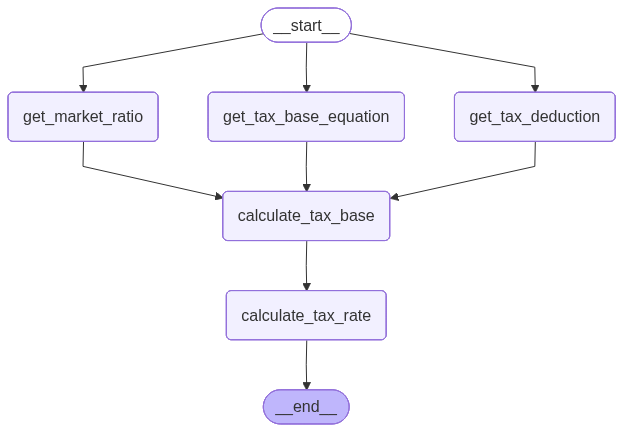

In [26]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
initial_state = {'query': query}
graph.invoke(initial_state)

tax_market_ratio web search: {'query': '오늘 날짜(2026-05-08)에 해당하는 주택 공시가격 공정시장가액비율은 몇 %인가요?', 'follow_up_questions': None, 'answer': '2026년 5월 8일 기준 일반 주택 공시 시장가액비율은 60%입니다. 1주택자의 비율은 43%에서 45% 사이입니다. 이 비율은 재산세 계산에 중요합니다.', 'images': ['https://on-estate.com/wp-content/uploads/2026/03/%EC%A0%9C%EB%AA%A9%EC%9D%84-%EC%9E%85%EB%A0%A5%ED%95%B4%EC%A3%BC%EC%84%B8%EC%9A%94.-13-1024x724.jpg', 'https://www.joseilbo.com/gisa_img_origin/17768184131776818413_rozzhj_origin.png', 'https://img.newspim.com/news/2025/08/18/2508181723068400.jpg', 'https://scs-phinf.pstatic.net/MjAyNjAzMjBfMTMw/MDAxNzc0MDA4NDQwNTIz.BOcgrmJeOKlu-kkmEJ2iUPJCy6Jj6dDM4lm3C3hiNfcg.EhCOn8JC85JZu7ZCdq4oXWCGLU6pD1h3zg7bWo-oxTEg.PNG/image.png?type=w800', 'https://drkjaf.com/wp-content/uploads/2026/03/featured-804.jpg'], 'results': [{'url': 'https://contents.premium.naver.com/doodle2/seobi0807/contents/260320211630875ct', 'title': '공정시장가액비율 뜻 2026 재산세 계산 핵심 3분 정리', 'content': '2026년 현재 일반 주택은 60%, 1세대 1주택자는 43~45%가 적용되고 있고, 이 비율이 얼마냐

{'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
 'answer': '주택 수가 총 3채이므로, 사용자는 3주택 이상을 소유한 경우에 해당합니다. 과세표준이 23억 원일 때의 종합부동산세를 계산하기 위해서 다음과 같은 세율을 사용해야 합니다:\n\n- 과세표준 12억 원 초과 25억 원 이하: 960만원 + (12억 원을 초과하는 금액의 12분의 13)\n\n과세표준이 23억 원이므로, 12억 원을 초과하는 금액은 23억 원 - 12억 원 = 11억 원입니다.\n\n따라서, 세액은 다음과 같이 계산됩니다:\n\n1. 초과 금액에 대한 세액: 11억 원 × (13/12) = 1억 1916만 6667원\n\n2. 총 세액: 960만원 + 1억 1916만 6667원 = 1억 2876만 6667원\n\n따라서, 사용자가 내야 할 종합부동산세는 약 1억 2877만 원이 됩니다. (정확한 금액은 천원 단위로 반올림하여 표시)',
 'tax_base_equation': '과세표준 = 공시가격 - 12억 원',
 'tax_deduction': '주택에 대한 종합부동산세 계산 시 1세대 1주택자인 경우 공제금액은 12억 원입니다.',
 'market_ratio': '2026년 5월 8일 기준 일반 주택의 공시 가격에 대한 공정시장가액비율은 60%입니다. 또한, 1주택자의 경우 공정시장가액비율은 43%에서 45% 사이입니다. 이 비율은 재산세 계산에 중요합니다.',
 'tax_base': '사용자의 주택이 1세대 1주택에 해당하지 않고 다주택인 경우, 각각의 주택에 대한 합산 공시가격에서 공제 금액을 제외하여 과세표준을 계산할 수 있습니다. \n\n주택 공시가격 합계:\n- 5억 원짜리 주택\n- 10억 원짜리 주택\n- 20억 원짜리 주택\n\n총 공시가격 합계 = 5억 원 + 10억 원 + 20억 원 = 35억 원\n\n공제금액: 12억 원\n\n과세표준 계산:\n과세표준 = 총 공시가격 합계 - 